In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
import torch
import torch.nn as nn

class rope(nn.Module):
    def __init__(self, seq_len, dk, base=10000.0):
        super().__init__()
        self.dk = dk
        
        # Build the frequency cache
        inv_freq = 1.0 / (base ** (torch.arange(0, dk, 2).float() / dk))
        t = torch.arange(seq_len).float()
        freqs = torch.outer(t, inv_freq)
        
        # Register buffers (seq_len, dk/2)
        self.register_buffer('rope_cos', freqs.cos())
        self.register_buffer('rope_sin', freqs.sin())

    def _apply_rope(self, x, cos, sin):
        # x shape: (seq_len, head_dim)
        # cos/sin shape: (seq_len, head_dim / 2)
        
        # Split into even and odd indices
        x_even, x_odd = x[..., 0::2], x[..., 1::2]
        
        # Since x and cos/sin share the same first dimension (seq_len), 
        # we don't need extra unsqueezing.
        out_even = x_even * cos - x_odd * sin
        out_odd = x_odd * cos + x_even * sin
        
        # Interleave and flatten back to (seq_len, head_dim)
        return torch.stack([out_even, out_odd], dim=-1).flatten(-2)

    def forward(self, x):
        # Slice the cache to match the input sequence length
        cos = self.rope_cos[:x.shape[0]]
        sin = self.rope_sin[:x.shape[0]]
        return self._apply_rope(x, cos, sin)

In [4]:
seq_len = 10000
dk = 128
n_experiments = 10

R = rope(seq_len,dk)
vec = torch.randn(dk) 
broadcasted = vec.unsqueeze(1).expand(dk, seq_len)
k = broadcasted.transpose(0,1)
k_roped = R(k)
q = torch.randn(n_experiments,dk)

In [24]:
k_roped.shape

torch.Size([10000, 128])

In [25]:
results = torch.matmul(q,k_roped.T)

similarity=0.03595908731222153


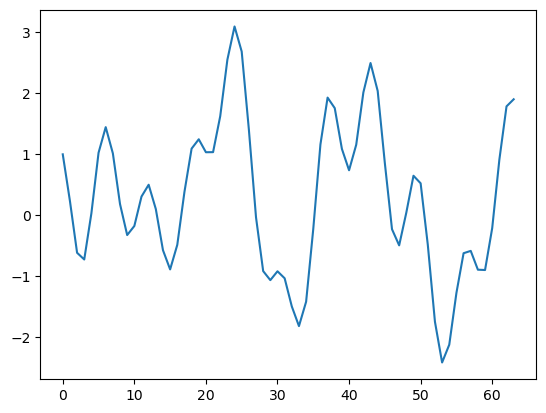

similarity=-0.18334637582302094


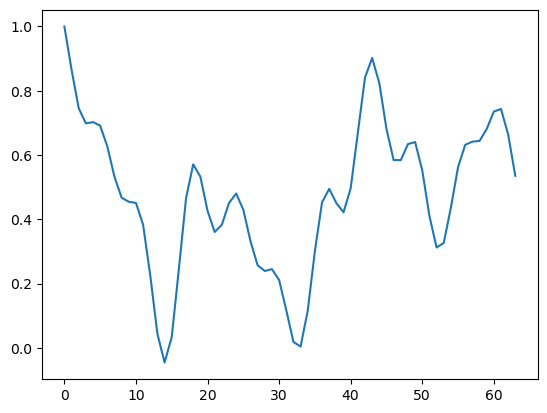

similarity=0.18397459387779236


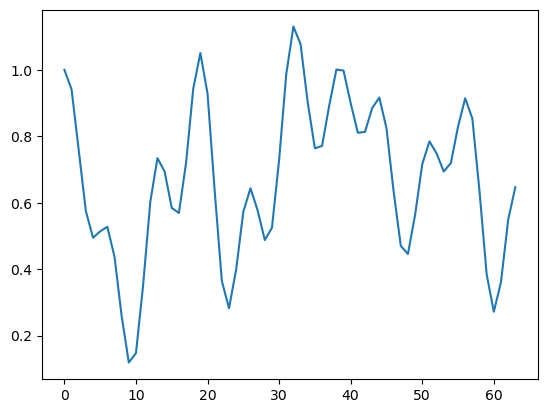

similarity=-0.04228336736559868


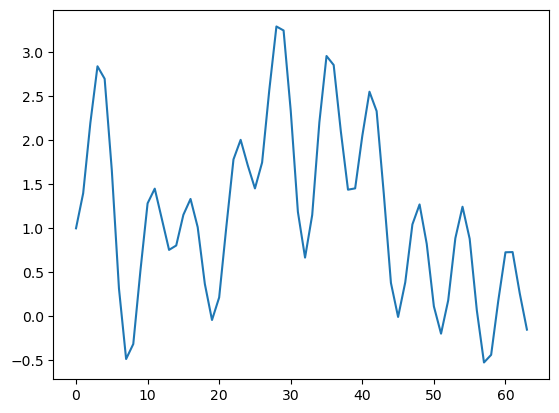

similarity=-0.022533874958753586


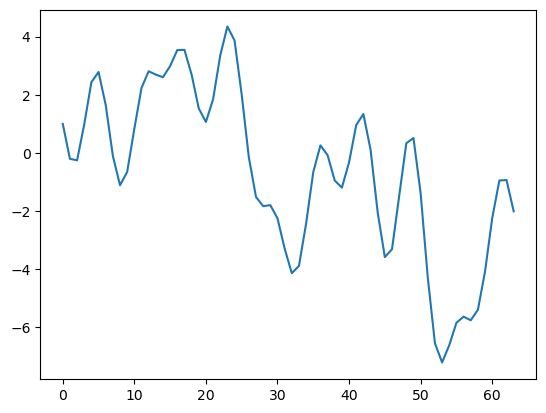

similarity=0.061879612505435944


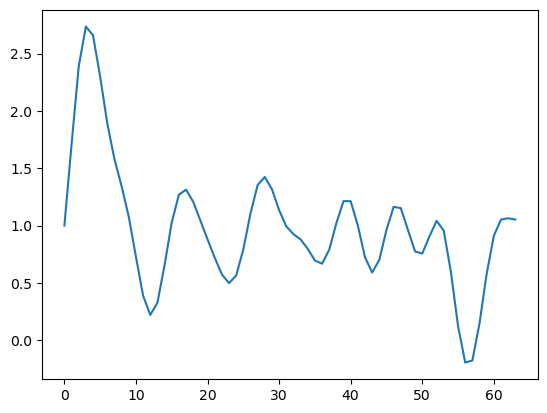

similarity=-0.018482433632016182


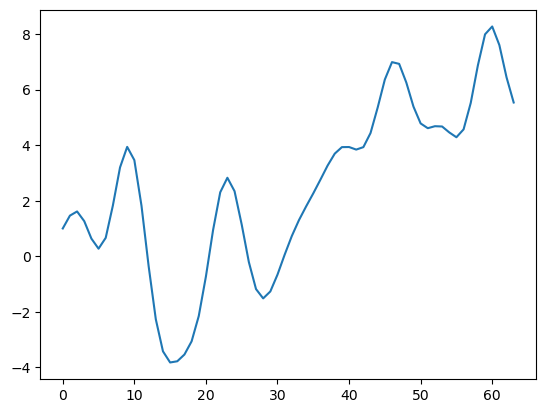

similarity=0.049713749438524246


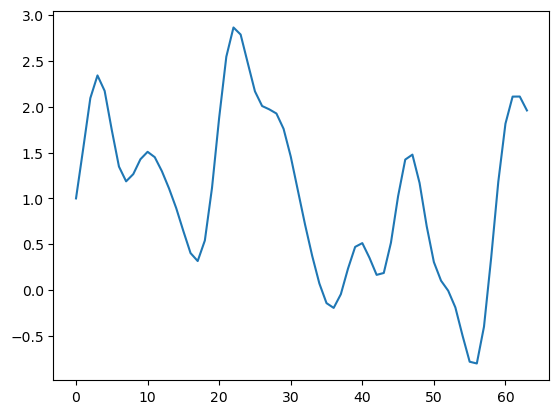

similarity=-0.05249985679984093


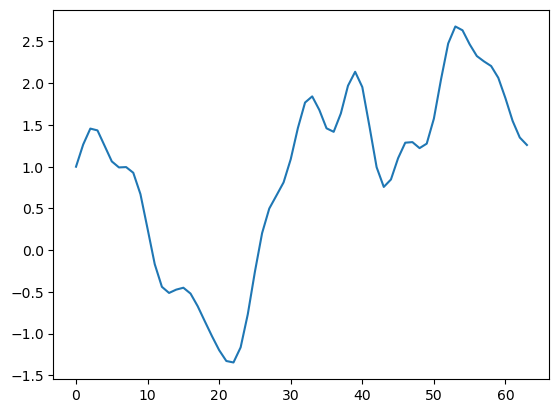

similarity=-0.01800898276269436


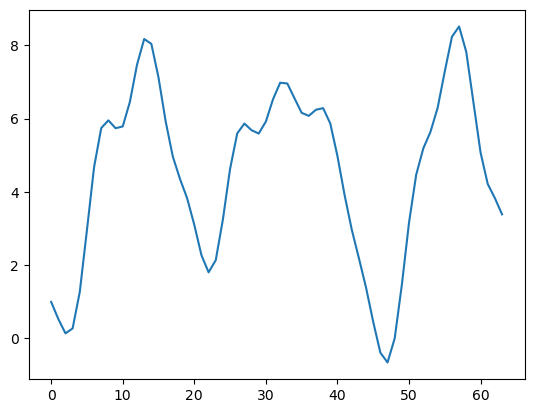

In [26]:
for i in range(n_experiments):
    print(f"similarity={results[i,0]/torch.norm(k_roped[0,:])/torch.norm(q[i,:])}")
    plt.plot(results[i,:64]/results[i,0])
    plt.show()

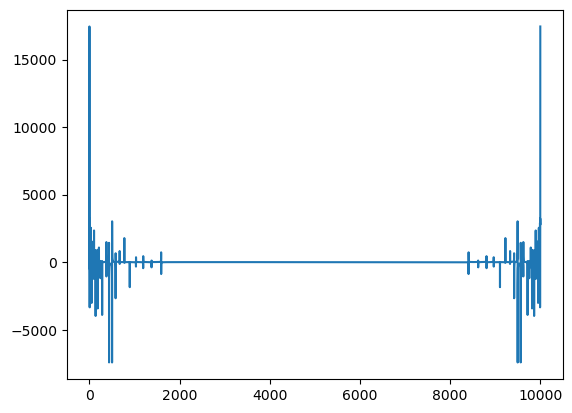

In [20]:
i=9
plt.plot(torch.fft.fft(results[i,:]/results[i,0]))
plt.show()